# 📊 Milestone 1: Data Cleaning & Exploratory Data Analysis

## Objective
To load, clean, and explore the FEMA disaster dataset to understand its structure, quality, and initial patterns.

## Tasks:
- Load dataset
- Handle missing values
- Fix data types
- Perform EDA
- Generate basic visualizations


In [12]:
# ==============================
# Import Libraries
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For better visuals
sns.set(style="whitegrid")

# ==============================
# Load Dataset
# ==============================

df = pd.read_csv("../dataset/us_disaster_declarations.csv")

# Show first 5 rows
df.head()


,fema_declaration_string,disaster_number,state,declaration_type,declaration_date,fy_declared,incident_type,declaration_title,ih_program_declared,ia_program_declared,...,place_code,designated_area,declaration_request_number,last_ia_filing_date,incident_id,region,designated_incident_types,last_refresh,hash,id
0,DR-1-GA,1,GA,DR,1953-05-02T00:00:00Z,1953,Tornado,Tornado,0,1,...,0,Statewide,53013,NaN,53013,4,NaN,2024-08-27T18:22:14Z,413ff808d79f08a6710f6b78f361d5a7de692711,8943dfcf-9786-4e51-8889-d62014034bb2
1,DR-2-TX,2,TX,DR,1953-05-15T00:00:00Z,1953,Tornado,Tornado & Heavy Rainfall,0,1,...,0,Statewide,53003,NaN,53003,6,W,2024-08-27T18:22:14Z,8a8bc885c003cb873c201bb6a3a2771a6d84efb1,ff821327-6b90-4246-b19f-fff8c4b288a8
2,DR-3-LA,3,LA,DR,1953-05-29T00:00:00Z,1953,Flood,Flood,0,1,...,0,Statewide,53005,NaN,53005,6,NaN,2024-08-27T18:22:14Z,b6e6f19ae3c0d2383b7b873b8495bd2770f2ff9a,cd461e08-5ac9-4e70-8507-9c7a3cbff265
3,DR-4-MI,4,MI,DR,1953-06-02T00:00:00Z,1953,Tornado,Tornado,0,1,...,0,Statewide,53004,NaN,53004,5,NaN,2024-08-27T18:22:14Z,34f0061012c8069f145d56a3537cd327b7d4e49b,53be0c04-d2ae-42fb-b070-a01b0a50b7f6
4,DR-5-MT,5,MT,DR,1953-06-06T00:00:00Z,1953,Flood,Floods,0,1,...,0,Statewide,53006,NaN,53006,8,NaN,2024-08-27T18:22:14Z,3bdbec258e4640c3f02971dbc1f9dbc3ebbfc96a,4b3ed0ac-299b-49f0-80d4-9a2a6bacd5a4


In [13]:
# Shape of dataset
df.shape


(68485, 27)

In [14]:
# Column names
df.columns

Index(['fema_declaration_string', 'disaster_number', 'state',
       'declaration_type', 'declaration_date', 'fy_declared', 'incident_type',
       'declaration_title', 'ih_program_declared', 'ia_program_declared',
       'pa_program_declared', 'hm_program_declared', 'incident_begin_date',
       'incident_end_date', 'disaster_closeout_date', 'tribal_request', 'fips',
       'place_code', 'designated_area', 'declaration_request_number',
       'last_ia_filing_date', 'incident_id', 'region',
       'designated_incident_types', 'last_refresh', 'hash', 'id'],
      dtype='str')

In [15]:
# Dataset info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 68485 entries, 0 to 68484
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   fema_declaration_string     68485 non-null  str  
 1   disaster_number             68485 non-null  int64
 2   state                       68485 non-null  str  
 3   declaration_type            68485 non-null  str  
 4   declaration_date            68485 non-null  str  
 5   fy_declared                 68485 non-null  int64
 6   incident_type               68485 non-null  str  
 7   declaration_title           68485 non-null  str  
 8   ih_program_declared         68485 non-null  int64
 9   ia_program_declared         68485 non-null  int64
 10  pa_program_declared         68485 non-null  int64
 11  hm_program_declared         68485 non-null  int64
 12  incident_begin_date         68485 non-null  str  
 13  incident_end_date           67963 non-null  str  
 14  disaster_closeout

In [16]:
# Missing values
df.isnull().sum()

fema_declaration_string           0
disaster_number                   0
state                             0
declaration_type                  0
declaration_date                  0
fy_declared                       0
incident_type                     0
declaration_title                 0
ih_program_declared               0
ia_program_declared               0
pa_program_declared               0
hm_program_declared               0
incident_begin_date               0
incident_end_date               522
disaster_closeout_date        16417
tribal_request                    0
fips                              0
place_code                        0
designated_area                   0
declaration_request_number        0
last_ia_filing_date           49090
incident_id                       0
region                            0
designated_incident_types     47812
last_refresh                      0
hash                              0
id                                0
dtype: int64

In [17]:
# ==============================
# Convert date columns
# ==============================

date_cols = [
    'declaration_date',
    'incident_begin_date',
    'incident_end_date',
    'disaster_closeout_date',
    'last_ia_filing_date'
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

In [18]:
# ==============================
# Data Cleaning (Final Working)
# ==============================

# Convert date columns
date_cols = [
    'declaration_date',
    'incident_begin_date',
    'incident_end_date',
    'disaster_closeout_date',
    'last_ia_filing_date'
]

for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')


# Drop column safely
df.drop(columns=['last_ia_filing_date'], inplace=True, errors='ignore')


# Fix missing dates
if 'incident_end_date' in df.columns:
    df['incident_end_date'] = df['incident_end_date'].ffill()

if 'disaster_closeout_date' in df.columns:
    df['disaster_closeout_date'] = df['disaster_closeout_date'].ffill()


# Fill categorical safely
if 'designated_incident_types' in df.columns:
    df['designated_incident_types'] = df['designated_incident_types'].fillna("Unknown")


# Remove duplicates
df.drop_duplicates(inplace=True)


# Final check
df.isnull().sum()

fema_declaration_string       0
disaster_number               0
state                         0
declaration_type              0
declaration_date              0
fy_declared                   0
incident_type                 0
declaration_title             0
ih_program_declared           0
ia_program_declared           0
pa_program_declared           0
hm_program_declared           0
incident_begin_date           0
incident_end_date             0
disaster_closeout_date        0
tribal_request                0
fips                          0
place_code                    0
designated_area               0
declaration_request_number    0
incident_id                   0
region                        0
designated_incident_types     0
last_refresh                  0
hash                          0
id                            0
dtype: int64

In [19]:
df['year'] = df['declaration_date'].dt.year

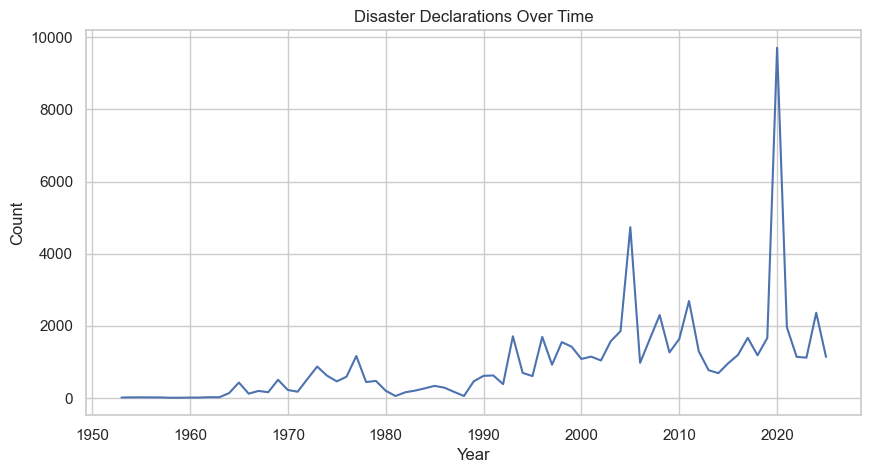

In [20]:
yearly = df['year'].value_counts().sort_index()

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
yearly.plot()
plt.title("Disaster Declarations Over Time")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

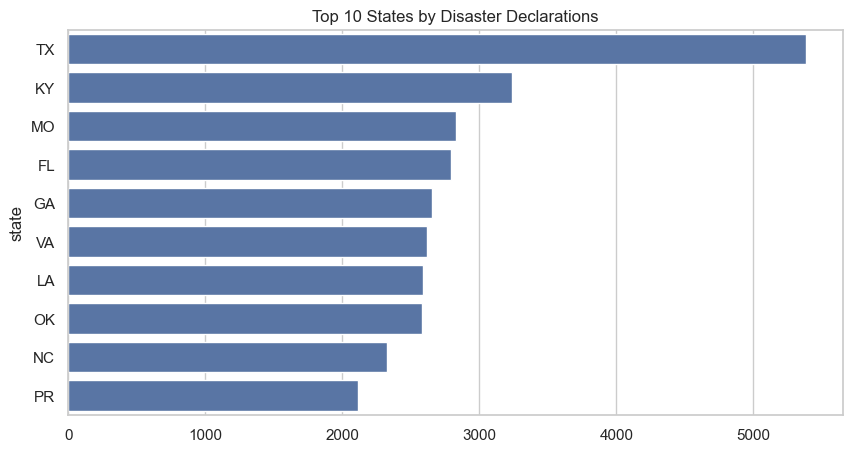

In [21]:
import seaborn as sns

top_states = df['state'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_states.values, y=top_states.index)
plt.title("Top 10 States by Disaster Declarations")
plt.show()

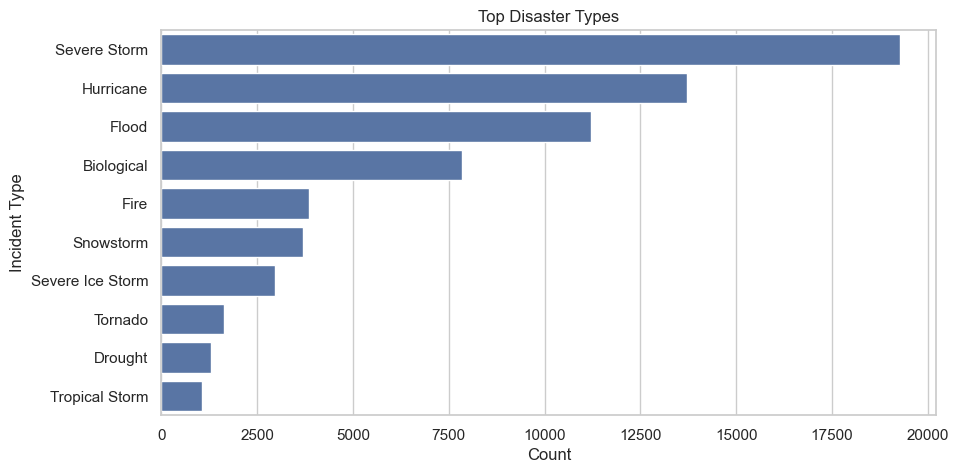

In [23]:
incident_counts = df['incident_type'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=incident_counts.values, y=incident_counts.index)
plt.title("Top Disaster Types")
plt.xlabel("Count")
plt.ylabel("Incident Type")
plt.show()

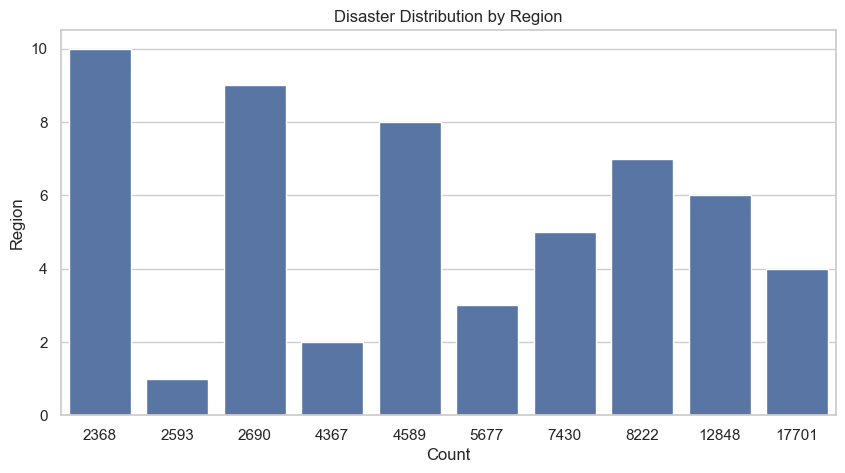

In [24]:
region_counts = df['region'].value_counts()

plt.figure(figsize=(10,5))
sns.barplot(x=region_counts.values, y=region_counts.index)
plt.title("Disaster Distribution by Region")
plt.xlabel("Count")
plt.ylabel("Region")
plt.show()

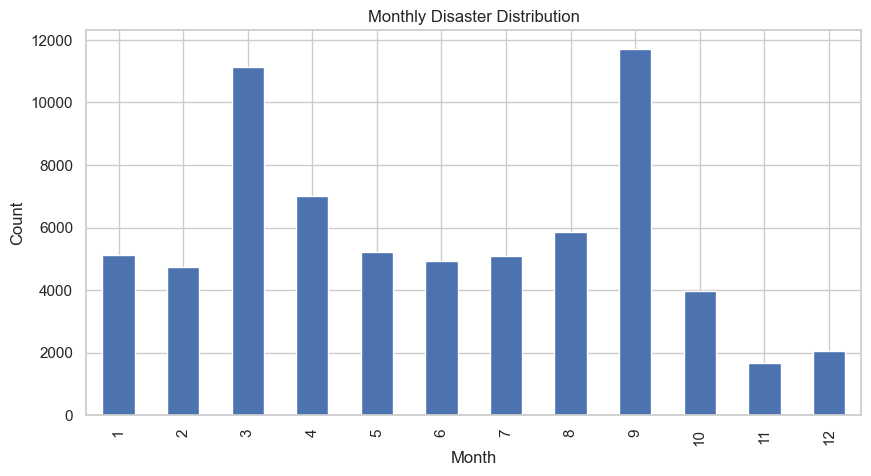

In [25]:
monthly = df['declaration_date'].dt.month.value_counts().sort_index()

plt.figure(figsize=(10,5))
monthly.plot(kind='bar')
plt.title("Monthly Disaster Distribution")
plt.xlabel("Month")
plt.ylabel("Count")
plt.show()

# 📊 Milestone 1 Conclusion

In this milestone, the FEMA disaster dataset was successfully loaded, cleaned, and explored.

### Key Work Done:
- Performed data cleaning by handling missing values and converting date columns.
- Conducted Exploratory Data Analysis (EDA) to understand dataset structure and patterns.
- Generated multiple visualizations including:
  - Year-wise disaster trends
  - Top states affected by disasters
  - Incident type distribution
  - Region-wise disaster analysis
  - Monthly disaster patterns

### Key Insights:
- Disaster declarations have increased over time.
- Certain states (like Texas, California, etc.) experience higher disaster frequency.
- Severe storms, hurricanes, and floods are the most common disaster types.
- Disaster occurrences show seasonal patterns across months.
- Some regions are more prone to disasters than others.

### Conclusion:
The dataset is now clean and well-understood, and initial patterns have been identified. This prepares the foundation for deeper temporal analysis in the next milestone.